In [ ]:
import torch
import os

import torch.nn.functional as F
import numpy as np
import pandas as pd
import pickle
import argparse
from river import metrics
from torch.autograd import Variable
import sys
import traceback
import pprint
import copy

from models.cgru import PiggyBackGRU

from GIN import *




In [ ]:
hidden_size = 100
hidden_mult = 50
batch_size = 128
seq_len = 11
epoch_num = 10
mask_init = '1s'
threshold_fn = "sigmoid"
device = "cuda"

dataset = "weather_11conf_train"
df = pd.read_csv(os.path.join("datasets/",f"{dataset}.csv"))
model = GIN(hidden_size = hidden_size, hidden_mult = hidden_mult, batch_size = batch_size, mask_init = mask_init, train_epochs= epoch_num,
                seq_len = seq_len, train_verbose = True, threshold_fn = threshold_fn,ensemble_mode = "average",device = device)


last_task = 1
state_dicts = {}
metrics_task = {}
for task in range(1, df["task"].max() + 1):
    metrics_dict = {"accuracy": metrics.BalancedAccuracy(),
          "kappa": metrics.CohenKappa()}
    df_task = df[df["task"] == task]
    df_task = df_task.drop(columns="task")
    for i in range(0, 128*60):
        x = df_task.iloc[i, 0:-1].values.astype(np.float32)
        y = df_task.iloc[i, -1]
        y_hat = model.predict_one(x)
        for metric in metrics_dict.values():
            metric.update(y,y_hat)
        model.learn_one(x,y)
    
    state_dicts[task] = model.get_state_dict()
    metrics_task[task] = metrics_dict
    model.add_new_column(task_id = task + 1)
    print("................NEW TASK................")
    










In [1]:
import pickle 
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")


data_list = []
data_names = []
checkpoint_list = []
for i in [1]:
    for j in range(1,31):
        data_names.append("weather"+ str(j))
        with open('performance\\TESTS_8concept\\sine_rw10_mode5_' + str(j) +'conf_train\performance_128_10.pkl', 'rb') as f:
            data_list.append(pickle.load(f))
        # with open('performance\\TESTS_8concept\\weather_' + str(j) +'conf_train\checkpoints_128_11_it0.pkl', 'rb') as f:
        #     checkpoint_list.append(pickle.load(f))
        
# for i in [1]:
#     for j in [3]:
#         data_names.append("sine"+ str(j))
#         with open('performance\\TESTS_8concept\\' + str(j) +'conf_train\performance_128_10.pkl', 'rb') as f:
#             data_list.append(pickle.load(f))

"""weather_"""




'weather_'

In [ ]:
from statistics import mean
from scipy.stats import shapiro, ttest_rel, wilcoxon, levene, ttest_ind, mannwhitneyu,friedmanchisquare
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import scikit_posthocs as sp
import numpy as np
from autorank import autorank, plot_stats
import scienceplots
plt.style.available


import numpy as np
#, "ieee"
plt.style.use(["science"])
plt.rcParams.update({"font.size": 10})
cm = 1 / 2.54

def plot_nemenyi(df,title,start):
    models_data = [list(df[c]) for c in df.columns]
    fried_stat, fried_p = stats.friedmanchisquare(*models_data)
    print("P", fried_p)
    data = np.array(models_data)
    nem = sp.posthoc_nemenyi_friedman(data.T)
    nem.columns = df.columns
    nem["index"] = list(df.columns)
    nem = nem.set_index("index")
    result = autorank(df, alpha=0.05, verbose=False, order='descending')
    plot_stats(result)
    fig = plt.gcf()
    if start:
        titlen = title + ", start$_{avg}$"
    else:
        titlen = title + ", end$_{avg}$"
    plt.title(titlen)
    fig.set_size_inches(6*cm, 4*cm)
    plt.tight_layout()
    plt.savefig(
        "/Users/Sandro/OneDrive/Documents/Uni/TESI/GIN/graphs/nem_" + title + str(start)+".eps",
        format="eps",
        dpi = 1000
    )

def createDF(data,metric):
    metric_df = pd.DataFrame({"index": range(0,len(data["GIN"]["task"][metric][0])),
                              #"cGRU_GIN":data["cGRU_GIN_anytime"]["task"][metric][it],
                            "GIN": data["GIN_anytime"]["task"][metric][0],
                            "ARF": data["ARF_anytime"]["task"][metric][0],
                            "ARF_TA": data["ARF_TA_anytime"]["task"][metric][0],
                            "cPNN": data["cPNN_anytime"]["task"][metric][0],
                            "cGRU": data["cGRU_anytime"]["task"][metric][0]})
    return metric_df

def createLinePlotsDrifts(data_list,checkpoint_list,metric,names,save = False):
    dfs = {}
    drifts = {}
    choices = {}
    for i,x in enumerate(data_list):
        dfs[i] = createDF(x,metric)
        drifts[i] = [a+12800 for a in data_list[i]["cGRU_anytime"]["drifts"][0]]
        choices[i] = GIN_driftchoices(checkpoint_list[i])
    i = 0
    for dataset in dfs.values():
        dfl = pd.melt(dataset,['index'])
        fig, ax = plt.subplots()
        ax.set_title(names[i])
        Piggies = plt.vlines([drifts[i][a] for a in choices[i]["PiggyMask"]],0,1,colors="black",linestyles="dashed")
        Expands = plt.vlines([drifts[i][a] for a in choices[i]["Expand"]],0,1,colors="black",linestyles="dotted")
        sns.lineplot(dfl,x="index", y="value",hue="variable")
        custom_lines = [
            Line2D([0], [0], color="black", linestyle="dashed", lw=1, label="Piggy Mask"),
            Line2D([0], [0], color="black", linestyle="dotted", lw=1, label="Expand"),
        ]
        handles, labels = ax.get_legend_handles_labels()

        # Combine all legend elements
        combined_handles = handles + custom_lines
        combined_labels = labels + ["Piggy Mask", "Expand"]

        # Add a single, combined legend to the bottom
        fig.legend(combined_handles, combined_labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.2), title="Legend")

        # Remove the legend from the axis to avoid duplication
        ax.legend().remove()
        fig.subplots_adjust(bottom=0.1)
        if save:
            plt.savefig("graphs\\"+names[i]+".png", bbox_inches="tight")
        # Add a second legend
        plt.show()
        
        i = i+1


def GIN_driftchoices(checkpoints,tasks = 8):
    drifts = {"PiggyMask":[],"Expand": []}
    for a in range(0,tasks-1):
        before = checkpoints["GIN_anytime"][a].manager.model.classifier[1].weight.size()
        after = checkpoints["GIN_anytime"][a+1].manager.model.classifier[1].weight.size()
        if before == after:
            drifts["PiggyMask"].append(a)
        else:
            drifts["Expand"].append(a)

    return drifts



def avgPerConcept(data_list = [], models = [], metrics = ["kappa"]):

    start = {}
    end = {}
    drifts = data_list[0]["GIN_anytime"]["drifts"][0]
    concept_length = drifts[1] - drifts[0]

    for model in models:

        start[model] = {}
        end[model] = {}

        for n,i in enumerate(drifts):

            start[model][n+2] = {}
            end[model][n+2] = {}

            for metric in metrics:
                
                start_list = []
                end_list = []

                for data in data_list:
                    
                    start_list.append(data[model]["task"][metric][0][i + 128*50])
                    end_list.append(data[model]["task"][metric][0][i + concept_length - 1])

                start[model][n+2][metric] = round(mean(start_list),2)
                end[model][n+2][metric] = round(mean(end_list),2)
            
    return start, end


def avgAllMetrics(data_list = [], models = [], metrics = []):

    allTotal = {}
    drifts = data_list[0]["ARF_TA_anytime"]["drifts"][0]
    concept_length = drifts[1] - drifts[0]

    for model in models:

        allTotal[model] = {}

        for metric in metrics:

            allTotal[model][metric] = {}
            start = []
            end = []
            n = len(drifts) * len(data_list)

            for data in data_list:

                for i in drifts:

                    start = start + [data[model]["task"][metric][0][i + 128*50]]
                    end = end + [data[model]["task"][metric][0][i + concept_length - 1]]
            
            allTotal[model][metric]["start"] = str(round(mean(start),2)) + " +- " +str(round(np.std(start),2))
            
            allTotal[model][metric]["end"] = str(round(mean(end),2)) + " +- " +str(round(np.std(end),2))
    
    return allTotal


def createTestDataset(data_list = [], models = [], drift = 1, start = True):

    drifts = data_list[0]["GIN_anytime"]["drifts"][0]
    drift_point = drifts[drift - 1]
    concept_length = drifts[1] - drifts[0]

    if start is True:
        data_point = 50*128
    else:
        data_point = concept_length - 1
    df = {}
    for model in models:
        df[model] = []
        for data in data_list:
            df[model].append(data[model]["task"]["kappa"][0][drift_point+data_point])

    return pd.DataFrame(df)


def dependentTest(a, b):
    diff = a - b
    _, p_norm = shapiro(diff)
    if p_norm > 0.05:
        _ , p = ttest_rel(a,b, alternative="greater")
    else:
        _ , p = wilcoxon(a, b, alternative="greater")
    return p

def independentTest(a,b):
    _, p_norm_a = shapiro(a)
    _, p_norm_b = shapiro(b)
    if p_norm_a > 0.05 and p_norm_b > 0.05:
        _, p_levene = levene(a,b)
        equal_var = False
        if p_levene > 0.05:
            equal_var = True
        _, p = ttest_ind(a, b, equal_var= equal_var, alternative="greater")
    else:
        _, p = mannwhitneyu(a, b, alternative="greater")

    return p


def statisticalTest(df, concepts8 = False):
    results = {}
    for model1 in df.columns:
        results[model1] = []
        for model2 in df.columns:
            if model1 == model2:
                continue
            if concepts8 or ("ARF" not in model1 and "ARF" not in model2):
                p = dependentTest(df[model1], df[model2])
                if p < 0.05:
                    results[model1].append(model2)
            else:
                p = independentTest(df[model1], df[model2])
                if p < 0.05:
                    results[model1].append(model2)
    return results

    

                
                    
            
def create8conceptDataset(data_list,models,start):
    drifts = data_list[0]["GIN_anytime"]["drifts"][0]
    concept_length = drifts[1] - drifts[0]

    if start is True:
        data_point = 50*128
    else:
        data_point = concept_length - 1
    df = {}
    for model in models:
        # if model == "ARF_TA_anytime":
        #     continue
        df[model] = []
        for data in data_list:
            l = []
            for drift in drifts:
                l.append(data[model]["task"]["kappa"][0][drift+data_point])
            df[model].append(mean(l))

    return pd.DataFrame(df)


def createLinePlots(data_list,metric,names,save = False):
    dfs = {}
    drifts = data_list[0]["GIN_anytime"]["drifts"][0]
    ends = drifts[1:2] + []
    for i,x in enumerate(data_list):
        dfs[i] = createDF(x,metric)
    i = 0
    dfs[0]["GIN"][:24104] = dfs[0]["cPNN"][:24104]
    starts = [x+50*128 for x in drifts]
    ends = drifts[1:3] + [len(dfs[0]["GIN"])-1]
    print(starts,ends)
    for dataset in dfs.values():


        for drift in drifts:
            dataset.loc[drift:(drift + 128), dataset.columns] = 0
        
        dfl = pd.melt(dataset,['index'])
        fig, ax = plt.subplots(figsize=(16*cm,6*cm))

        custom_colors = ["#ff7f0e", "#d62728", "#9467bd","#2ca02c", "#1f77b4"]
        sns.set_palette(custom_colors)

        Starts = plt.vlines(starts,0,1,colors="gray",linestyles="dashed")
        Ends = plt.vlines(ends,0,1,colors="gray",linestyles="dashed")

        for z, s in enumerate(drifts):
            ax.text(s,  -0.02, "drift"+f"$_{{{z+1}}}$", rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=8, color="black")
        
        for i, s in enumerate(starts):
            ax.text(s+300, 1, "Start"+f"$_{{{i+1}}}$", rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=8, color="gray")

        for j, e in enumerate(ends):
            ax.text(e+300, 1, "End"+f"$_{{{j+1}}}$", rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=8, color="gray")


        sns.lineplot(dfl,x="index", y="value",hue="variable")
        plt.legend(title="", frameon = False)
        ax.set_xlim(0,ends[-1])
        ax.set_xlabel("")
        ax.set_ylabel("Cohen's Kappa")
        ax.set_ylim(0, 1)
        #ax.set_yticks([0,0.2,.4,.6,.8,1])
        ax.set_xticks([])
        ax.set_xticklabels([])
        # Add a second legend
        if save:
            plt.savefig("/Users/Sandro/OneDrive/Documents/Uni/TESI/GIN/graphs/4concept ex.eps",
                        format="eps",
                        dpi=1000)
        plt.show()
        
        i = i+1



[[24105, 48210, 72315]]
[30505, 54610, 78715] [48210, 72315, 96421]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


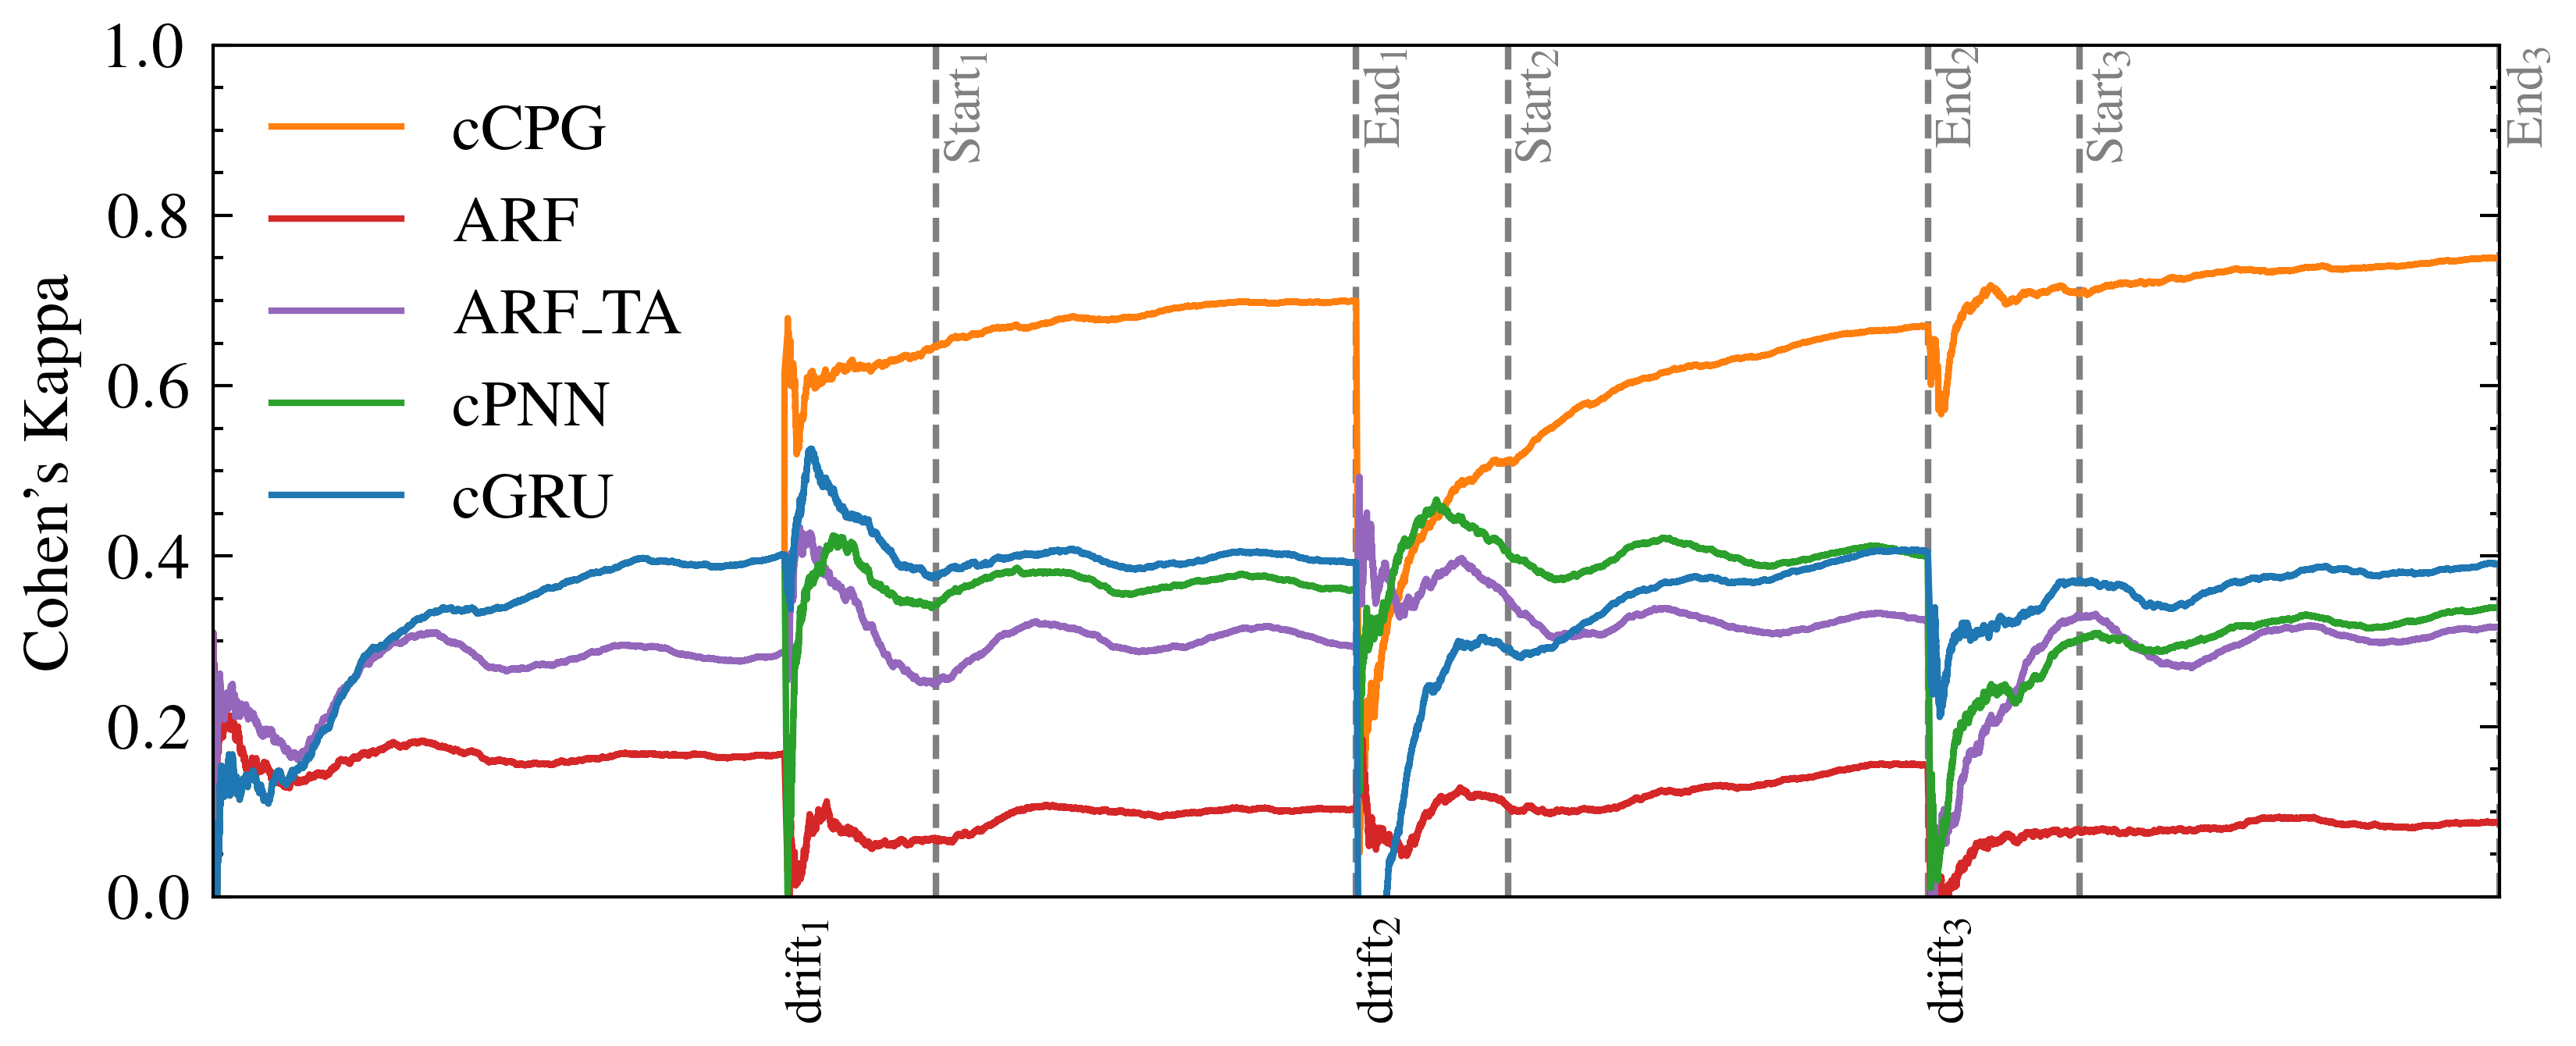

In [ ]:
print(data_list[0]["GIN_anytime"]["drifts"])
createLinePlots(data_list,"kappa",data_names,True)

In [5]:
import json
#df = createLinePlots(data_list,"kappa",names=data_names,save=False)
#df = createLinePlotsDrifts(data_list,checkpoint_list,"kappa",names=data_names,save=False)
start, end = avgPerConcept(data_list, data_list[0].keys())

#metrics = avgAllMetrics(data_list, data_list[0].keys(),["kappa"])

#df = createTestDataset(data_list, data_list[0].keys(), drift= 1, start = True)

In [7]:
#json.dumps(metrics)
print(start)

{'ARF_anytime': {2: {'kappa': 0.24}, 3: {'kappa': 0.25}, 4: {'kappa': 0.26}, 5: {'kappa': 0.26}, 6: {'kappa': 0.25}, 7: {'kappa': 0.25}, 8: {'kappa': 0.26}}, 'ARF_TA_anytime': {2: {'kappa': 0.73}, 3: {'kappa': 0.73}, 4: {'kappa': 0.73}, 5: {'kappa': 0.73}, 6: {'kappa': 0.73}, 7: {'kappa': 0.73}, 8: {'kappa': 0.73}}, 'cGRU_anytime': {2: {'kappa': 0.72}, 3: {'kappa': 0.69}, 4: {'kappa': 0.68}, 5: {'kappa': 0.67}, 6: {'kappa': 0.66}, 7: {'kappa': 0.65}, 8: {'kappa': 0.65}}, 'cPNN_anytime': {2: {'kappa': 0.71}, 3: {'kappa': 0.71}, 4: {'kappa': 0.68}, 5: {'kappa': 0.58}, 6: {'kappa': 0.54}, 7: {'kappa': 0.49}, 8: {'kappa': 0.52}}, 'cCPG_anytime': {2: {'kappa': 0.73}, 3: {'kappa': 0.72}, 4: {'kappa': 0.73}, 5: {'kappa': 0.74}, 6: {'kappa': 0.77}, 7: {'kappa': 0.76}, 8: {'kappa': 0.78}}}


In [8]:
import json
testResults={}

for j in [1,2,3,4]:
    name = 'sine_' + str(j)
    data_list = []
    data_names = []
    for i in range(0,10):
        data_names.append("sine"+ str(j))
        with open('performance\\TESTS_4concept\\Test_' + str(i) + '\\sine_rw10_mode5_' + str(j) +'conf\performance_128_10.pkl', 'rb') as f:
            data_list.append(pickle.load(f))
    testResults[name] = {}
    for drift in [1,2,3]:
        testResults[name][drift] = {}
        for start in [True, False]:
            df = createTestDataset(data_list, data_list[0].keys(), drift= drift, start = start)
            testResults[name][drift][start] = statisticalTest(df)


json.dumps(testResults)

'{"sine_1": {"1": {"true": {"ARF_anytime": [], "ARF_TA_anytime": ["ARF_anytime", "cGRU_anytime", "cPNN_anytime", "cCPG_anytime"], "cGRU_anytime": ["ARF_anytime", "cPNN_anytime"], "cPNN_anytime": ["ARF_anytime"], "cCPG_anytime": ["ARF_anytime", "cPNN_anytime"]}, "false": {"ARF_anytime": [], "ARF_TA_anytime": ["ARF_anytime", "cGRU_anytime", "cPNN_anytime", "cCPG_anytime"], "cGRU_anytime": ["ARF_anytime"], "cPNN_anytime": ["ARF_anytime"], "cCPG_anytime": ["ARF_anytime", "cGRU_anytime", "cPNN_anytime"]}}, "2": {"true": {"ARF_anytime": [], "ARF_TA_anytime": ["ARF_anytime"], "cGRU_anytime": ["ARF_anytime", "ARF_TA_anytime"], "cPNN_anytime": ["ARF_anytime", "ARF_TA_anytime", "cGRU_anytime", "cCPG_anytime"], "cCPG_anytime": ["ARF_anytime", "ARF_TA_anytime"]}, "false": {"ARF_anytime": [], "ARF_TA_anytime": ["ARF_anytime"], "cGRU_anytime": ["ARF_anytime", "ARF_TA_anytime"], "cPNN_anytime": ["ARF_anytime", "ARF_TA_anytime", "cGRU_anytime", "cCPG_anytime"], "cCPG_anytime": ["ARF_anytime", "ARF_TA_

P 2.6255241114842633e-22


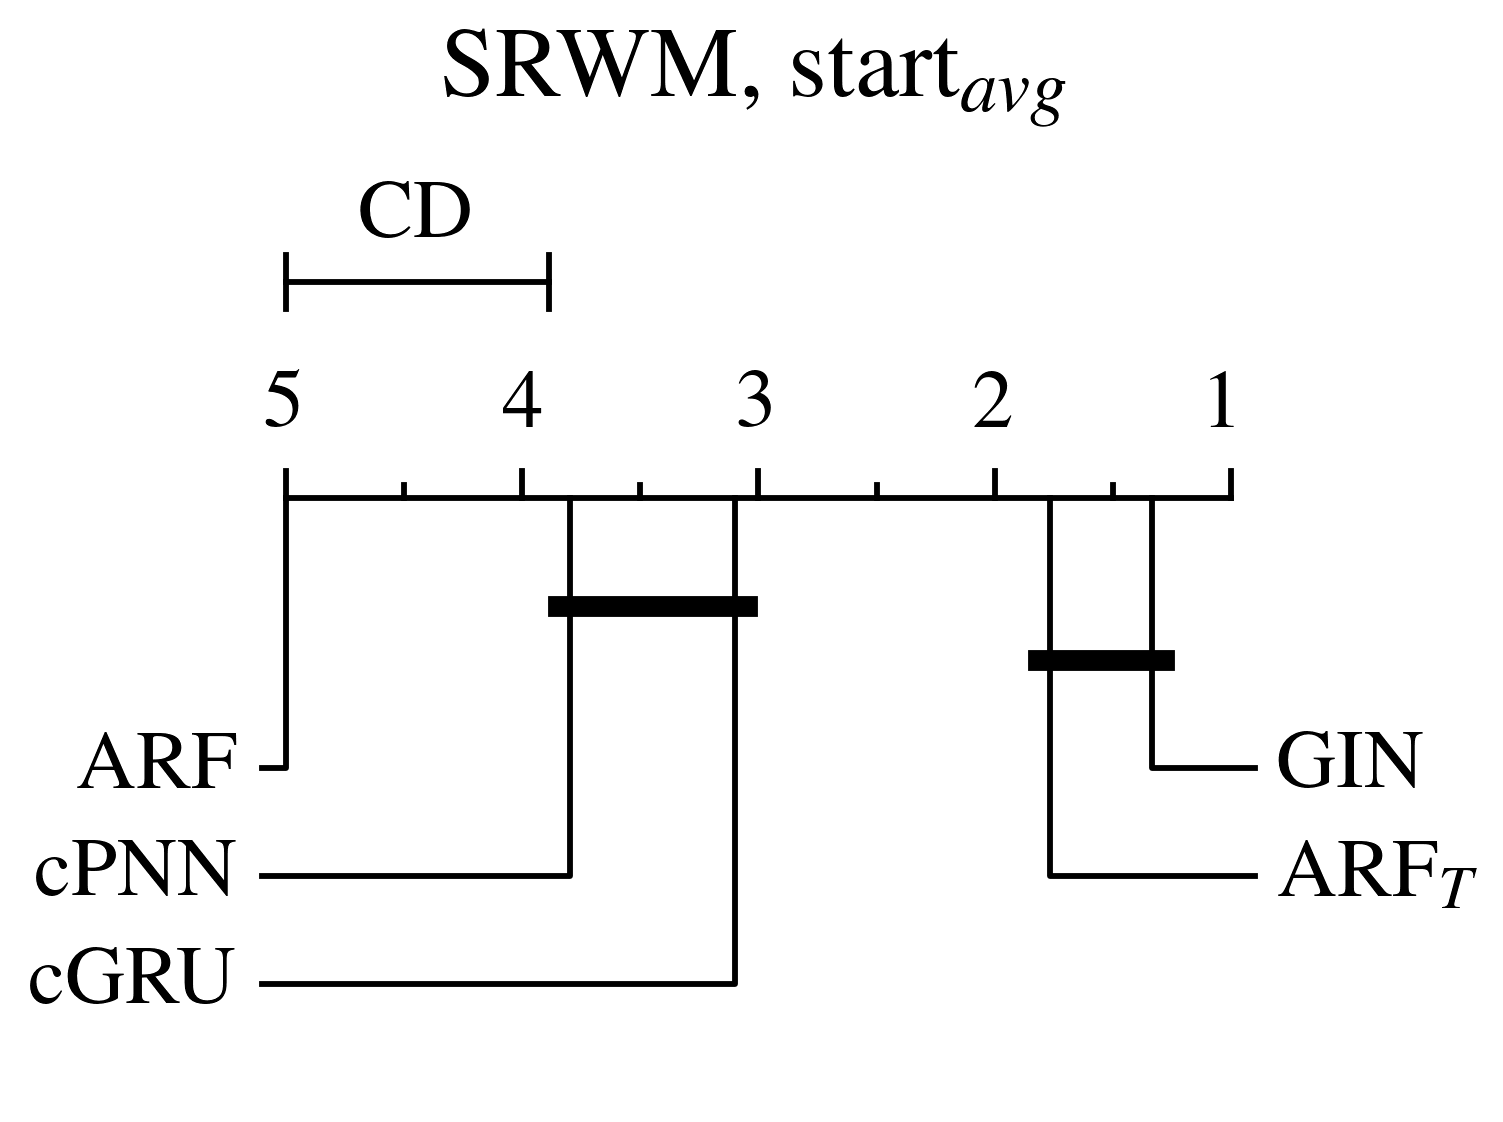

In [ ]:
start = True
title = "SRWM"

df = create8conceptDataset(data_list,data_list[0].keys(), start)



translation = {
    "ARF_anytime":"ARF",
    "cPNN_anytime":"cPNN",
    "ARF_TA_anytime":"ARF$_T$",
    "GIN_anytime":"GIN",
    "cGRU_anytime":"cGRU",
}
df.rename(columns=translation, inplace=True)

plot_nemenyi(df,title, start)
#statisticalTest(df, concepts8= True)

In [1]:
def countChoices(data_list):
    choices = {}
    for drift in [2,3,4]:
        choices[drift] = {}
        choices[drift]["PiggyMask"] = 0
        choices[drift]["Expand"] = 0
        if drift != 2:
            choices[drift]["PiggyMask_last"] = 0
            choices[drift]["Expand_last"] = 0
        for data in data_list:
            choices[drift][data[drift]] += 1
    return choices
            




import json
import pickle
choices={}

for j in [1,2,3,4]:
    name = 'sine_' + str(j)
    data_list = []
    data_names = []
    for i in range(0,10):
        data_names.append("sine"+ str(j))
        with open('performance\\TESTS_4concept_expansion\\Test_' + str(i) + '\\sine_rw10_mode5_' + str(j) +'conf\choices_it0.pkl', 'rb') as f:
            data_list.append(pickle.load(f))
    choices[name] = countChoices(data_list)

for j in [1,2,3,4]:
    name = 'weather_' + str(j)
    data_list = []
    data_names = []
    for i in range(0,10):
        data_names.append("sine"+ str(j))
        with open('performance\\TESTS_4concept_expansion\\Test_' + str(i) + '\\weather_' + str(j) +'conf\choices_it0.pkl', 'rb') as f:
            data_list.append(pickle.load(f))
    choices[name] = countChoices(data_list)


In [2]:
choices

{'sine_1': {2: {'PiggyMask': 10, 'Expand': 0},
  3: {'PiggyMask': 0, 'Expand': 1, 'PiggyMask_last': 9, 'Expand_last': 0},
  4: {'PiggyMask': 2, 'Expand': 0, 'PiggyMask_last': 8, 'Expand_last': 0}},
 'sine_2': {2: {'PiggyMask': 3, 'Expand': 7},
  3: {'PiggyMask': 4, 'Expand': 1, 'PiggyMask_last': 5, 'Expand_last': 0},
  4: {'PiggyMask': 4, 'Expand': 0, 'PiggyMask_last': 1, 'Expand_last': 5}},
 'sine_3': {2: {'PiggyMask': 10, 'Expand': 0},
  3: {'PiggyMask': 0, 'Expand': 2, 'PiggyMask_last': 8, 'Expand_last': 0},
  4: {'PiggyMask': 0, 'Expand': 1, 'PiggyMask_last': 8, 'Expand_last': 1}},
 'sine_4': {2: {'PiggyMask': 3, 'Expand': 7},
  3: {'PiggyMask': 4, 'Expand': 1, 'PiggyMask_last': 2, 'Expand_last': 3},
  4: {'PiggyMask': 6, 'Expand': 0, 'PiggyMask_last': 3, 'Expand_last': 1}},
 'weather_1': {2: {'PiggyMask': 10, 'Expand': 0},
  3: {'PiggyMask': 0, 'Expand': 5, 'PiggyMask_last': 0, 'Expand_last': 5},
  4: {'PiggyMask': 1, 'Expand': 0, 'PiggyMask_last': 9, 'Expand_last': 0}},
 'weather

In [2]:
import pickle 
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")


data_list = []
data_names = []
checkpoint_list = []
for i in [1]:
    for j in range(1,31):
        data_names.append("weather"+ str(j))
        with open('performance\\TESTS_8concept\\sine_rw10_mode5_' + str(j) +'conf_train\cl_metrics_128_10.pkl', 'rb') as f:
            data_list.append(pickle.load(f))
        # with open('performance\\TESTS_8concept\\weather_' + str(j) +'conf_train\checkpoints_128_11_it0.pkl', 'rb') as f:
        #     checkpoint_list.append(pickle.load(f))

In [ ]:
import copy
import json
from statistics import mean
def CLdataset(data_list, metric):
    df = {}
    for model in data_list[0].keys():
        list = []
        for data in data_list:
            list.append(data[model]["kappa"][0][metric])
        df[model] = list

    return pd.DataFrame(df,columns=df.keys())


def avgCL(data_list):
    results = {}
    for model in data_list[0].keys():
        AVG = []
        A = []
        BWT = []
        for data in data_list:
            AVG.append(data[model]["kappa"][0]["average"])
            A.append(data[model]["kappa"][0]["a_metric"])
            BWT.append(data[model]["kappa"][0]["bwt"])
        results[model] = {
            "average": str(round(mean(AVG),2)) + " +- " +str(round(np.std(AVG),2)),
            "a_metric": str(round(mean(A),2)) + " +- " +str(round(np.std(A),2)),
            "bwt": str(round(mean(BWT),2)) + " +- " +str(round(np.std(BWT),2))
            }
    return results


def avgSizeCL(data_list):
    results = {}
    models = ["cPNN","cGRU","GIN", "GIN w/Stored Masks"]
    for model in models:
        size = {}
        for concept in range(0,8):
            size[concept] = []
        for data in data_list:
            for concept in range(0,8):
                if model == "GIN w/Stored Masks":
                    size[concept].append(sum(data["GIN"]["memory"][0][concept]))
                elif model == "GIN":
                    size[concept].append(data["GIN"]["memory"][0][concept][1])
                else:
                    size[concept].append(data[model]["memory"][0][concept])
        for concept, list in size.items():
            size[concept] = mean(list)
        results[model] = size
    return results
    

def sizeGraph(df):

    fig, ax = plt.subplots(figsize= (7.5 *cm,6.5 *cm))
    plt.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)

    lines = sns.lineplot(data=df, ax=ax,linestyle="-",palette={"GIN w/Stored Masks": "#ff7f0e", "cPNN": "#2ca02c", "cGRU": "#1f77b4", "GIN": "#ff7f0e"})

    colors = [line.get_color() for line in lines.get_lines()]

    

    handles, labels = ax.get_legend_handles_labels()
    for column,handle in zip(df.columns,handles):
        if column == "GIN w/Stored Masks":
            handle.set_linestyle("dashed")
        else:
            handle.set_linestyle("-")

    # Update legend
    ax.legend(handles, labels, title="")

    for column, line in zip(df.columns,lines.get_lines()):
        if column == "GIN w/Stored Masks":
            line.set_linestyle("dashed")
        else:
            line.set_linestyle("-")

    # Overlay small markers with matching colors
    for column, color in zip(df.columns, colors):
        ax.scatter(df.index, df[column], s=10, color=color, label="_nolegend_")  # s=10 makes markers small


    ax.set_title("Weather")
    ax.set_ylim(0,3)
    ax.set_xlabel("True concepts",loc="right")
    ax.set_ylabel("Model Size[MB]",loc="top")
    # Add a second legend
    plt.savefig(
        "/Users/Sandro/OneDrive/Documents/Uni/TESI/GIN/graphs/sizeWeather.eps",
        format="eps",
        dpi = 1000
    )
    plt.show()
    



import numpy as np
import scienceplots
#, "ieee"
plt.style.use(["science"])
plt.rcParams.update({"font.size": 9})
cm = 1 / 2.54

def CL_kappa_graph(data_list,models =["cGRU","cPNN","GIN"]):
    
    results = {}
    concepts = range(0,8)
    for model in models:
        results[model] = {}
        for concept in concepts:
            results[model][concept] = []
    
    for data in data_list:
        for model in models:
            for concept in concepts:
                results[model][concept].append(mean(data[model]["kappa"][0][concept][:concept+1]))
    df_dict = {}            
    for model in models:
            list = []
            for concept in concepts:
                
                list.append(mean(results[model][concept]))
            if model == "GIN":
                df_dict["GIN"] = list
            else:    
                df_dict[model] = list

    df_dict["concept"] = ["c"+f"$_{{{z}}}$" for z in concepts]
    df = pd.DataFrame(df_dict)
    df = df.set_index("concept")

    fig, ax = plt.subplots(figsize= (7.5 *cm,6.5 *cm))
    plt.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False)


    fig.set_dpi(1000)
    lines = sns.lineplot(data=df, ax=ax,linestyle="-")

    colors = [line.get_color() for line in lines.get_lines()]

    handles, labels = ax.get_legend_handles_labels()
    for handle in handles:
        handle.set_linestyle("-")  # Set all legend lines to solid

    # Update legend
    ax.legend(handles, labels, title="")

    for line in lines.get_lines():
        line.set_linestyle("-")

    # Overlay small markers with matching colors
    for column, color in zip(df.columns, colors):
        ax.scatter(df.index, df[column], s=10, color=color, label="_nolegend_")  # s=10 makes markers small


    ax.set_title("SRWM")
    ax.set_xlabel("True concepts",loc="right")
    ax.set_ylabel("Cohen's Kappa",loc="top")
    ax.set_ylim(0, 1)

    plt.savefig(
        "/Users/Sandro/OneDrive/Documents/Uni/TESI/GIN/graphs/CLgraph_SRWM.eps",
        format="eps",
        dpi = 1000
    )
    # Add a second legend
    plt.show()
    
def avgExpansions(data_list):
    list = []
    for data in data_list:
        counter = 0
        for concept in range(1,8):
            if data["GIN"]["memory"][0][concept][1] > data["GIN"]["memory"][0][concept-1][1]:
                counter += 1
        list.append(counter)
    print(list)
    return mean(list)
                    


In [59]:
import torch
import os
def get_size(model):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1e6
    os.remove("temp.p")
    return size

In [37]:
avgExpansions(data_list)

[4, 4, 3, 4, 2, 3, 3, 5, 2, 2, 2, 3, 2, 1, 4, 3, 5, 5, 2, 4, 1, 2, 2, 2, 2, 1, 5, 2, 4, 3]


2.9

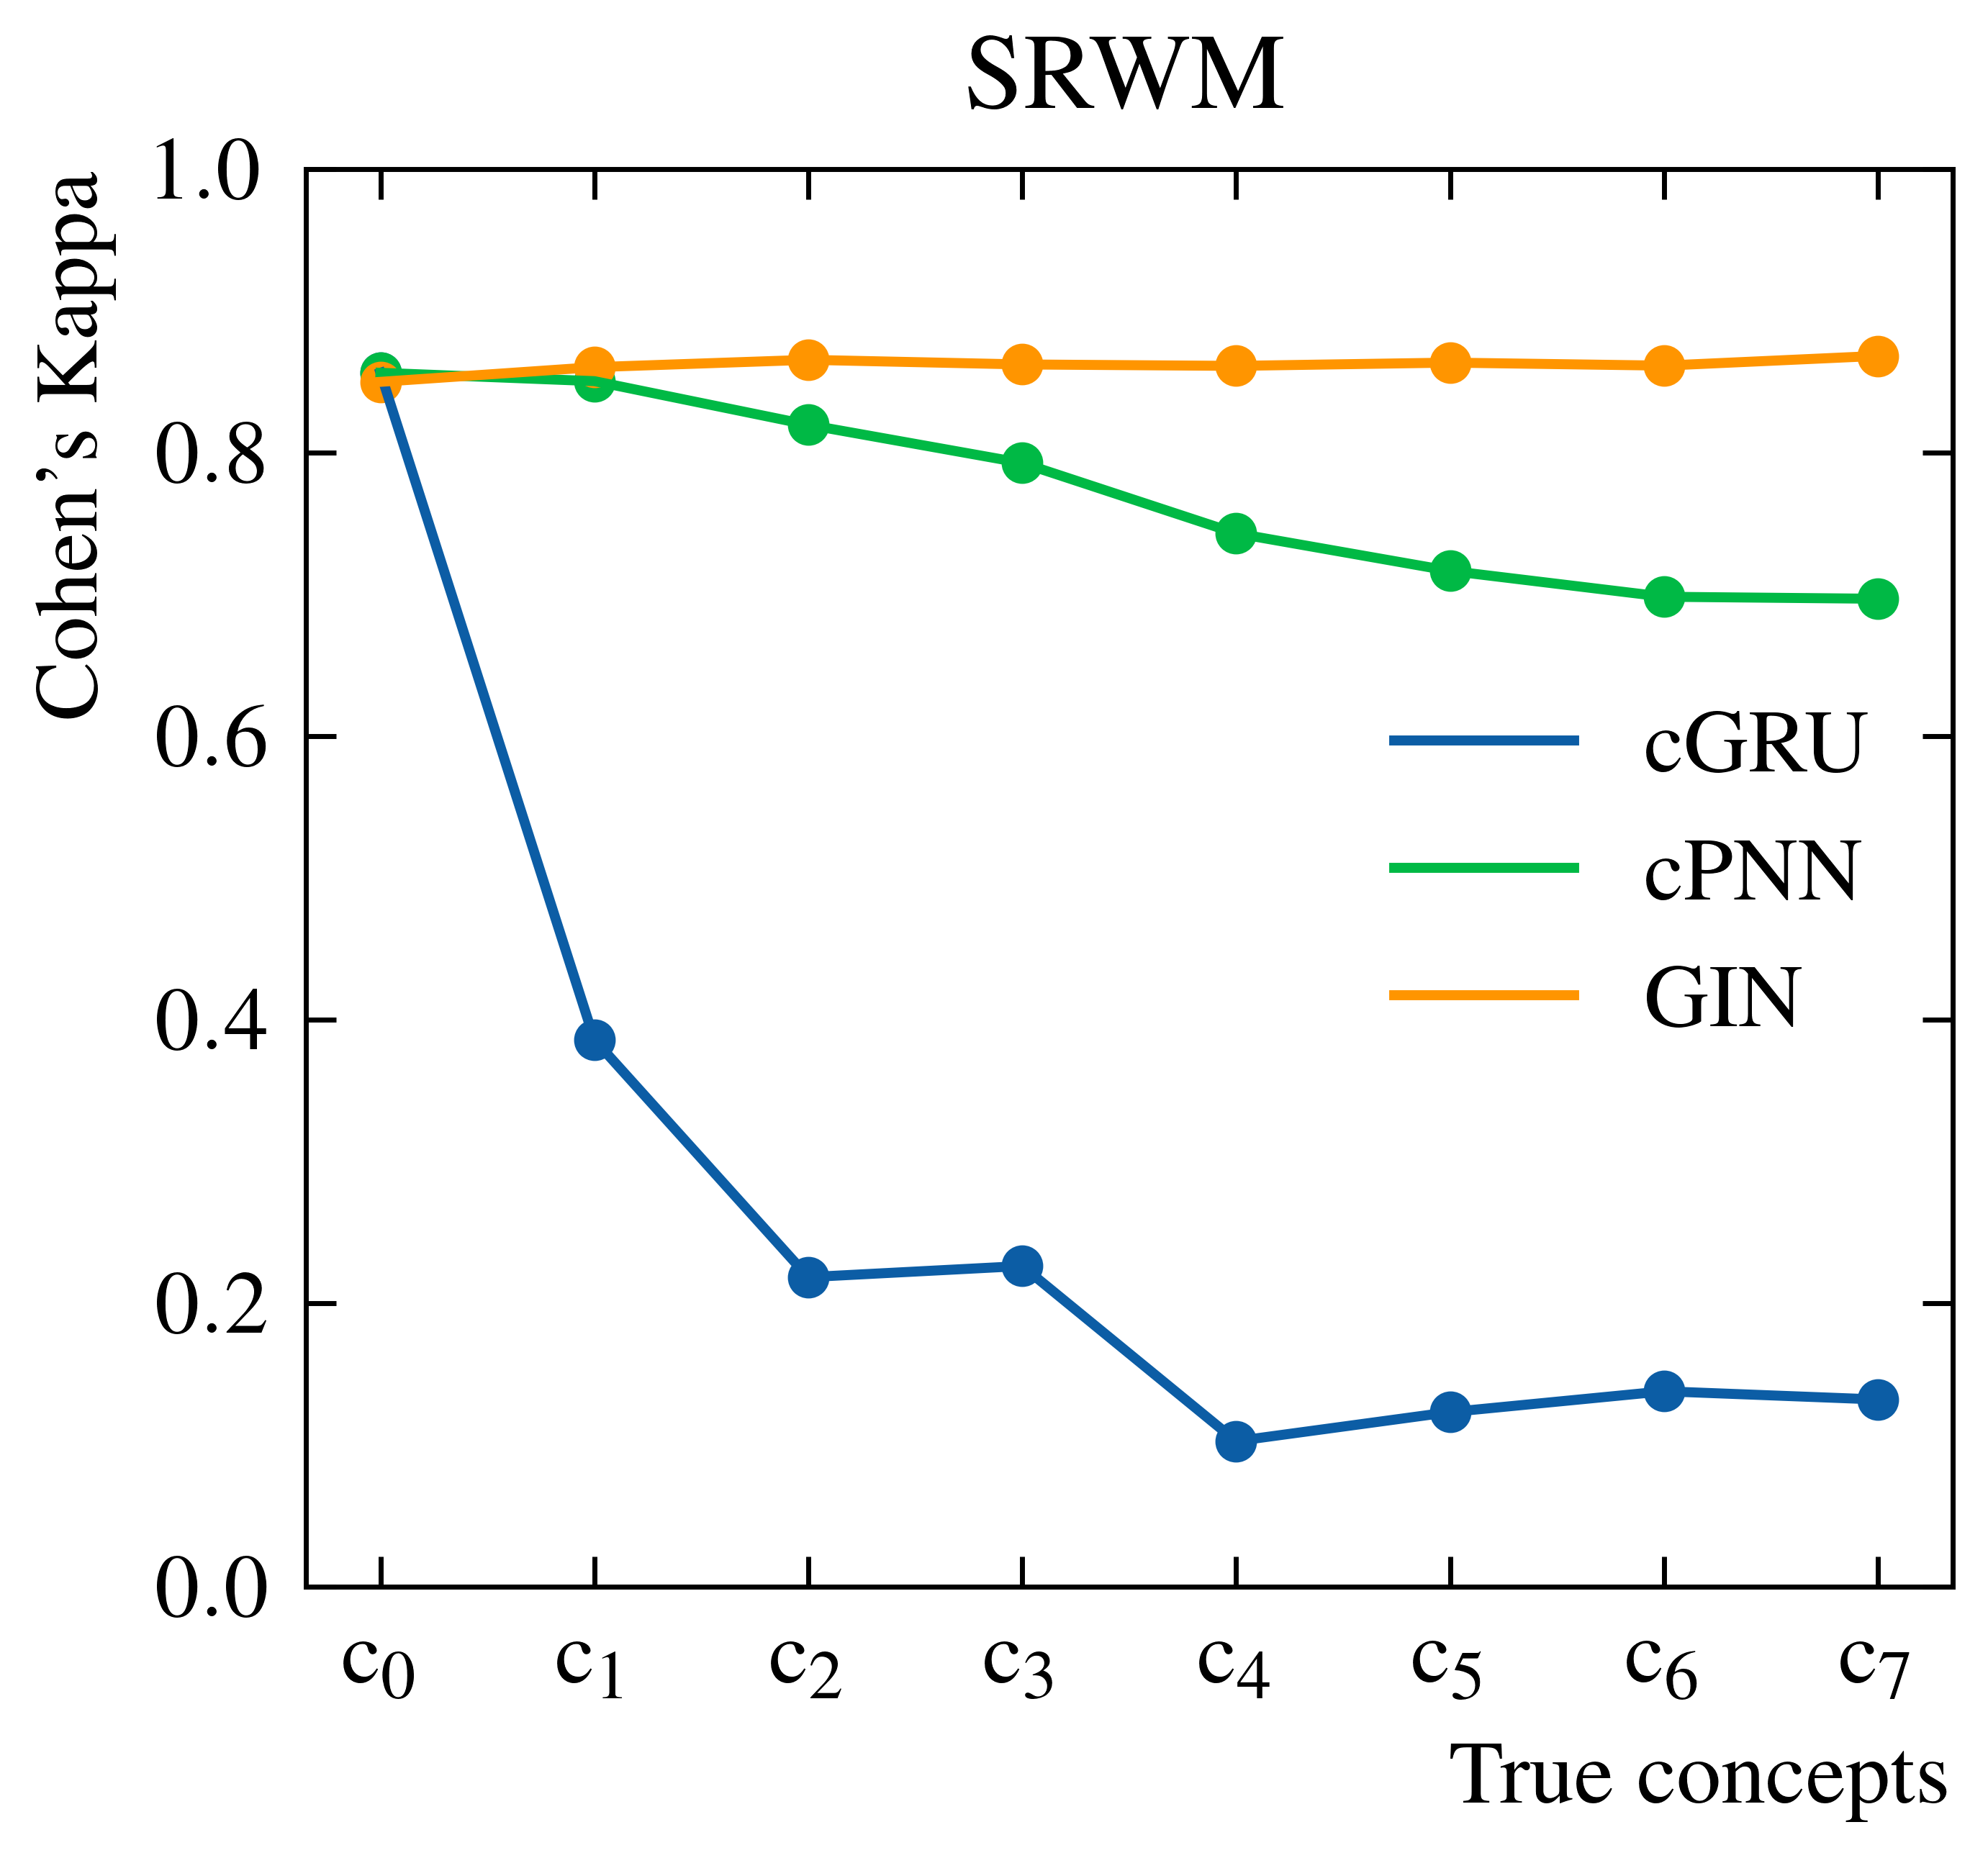

In [36]:
CL_kappa_graph(data_list)

In [14]:
metrics = avgCL(data_list)
json.dumps(metrics)

'{"ARF_TA": {"average": "0.22 +- 0.15", "a_metric": "0.2 +- 0.05", "bwt": "-0.24 +- 0.06"}}'

In [4]:
df = CLdataset(data_list,"bwt")

statisticalTest(df,True)

{'ARF': ['cGRU'],
 'ARF_TA': ['ARF', 'cGRU'],
 'cPNN': ['ARF', 'cGRU'],
 'cGRU': [],
 'cCPG': ['ARF', 'cGRU']}

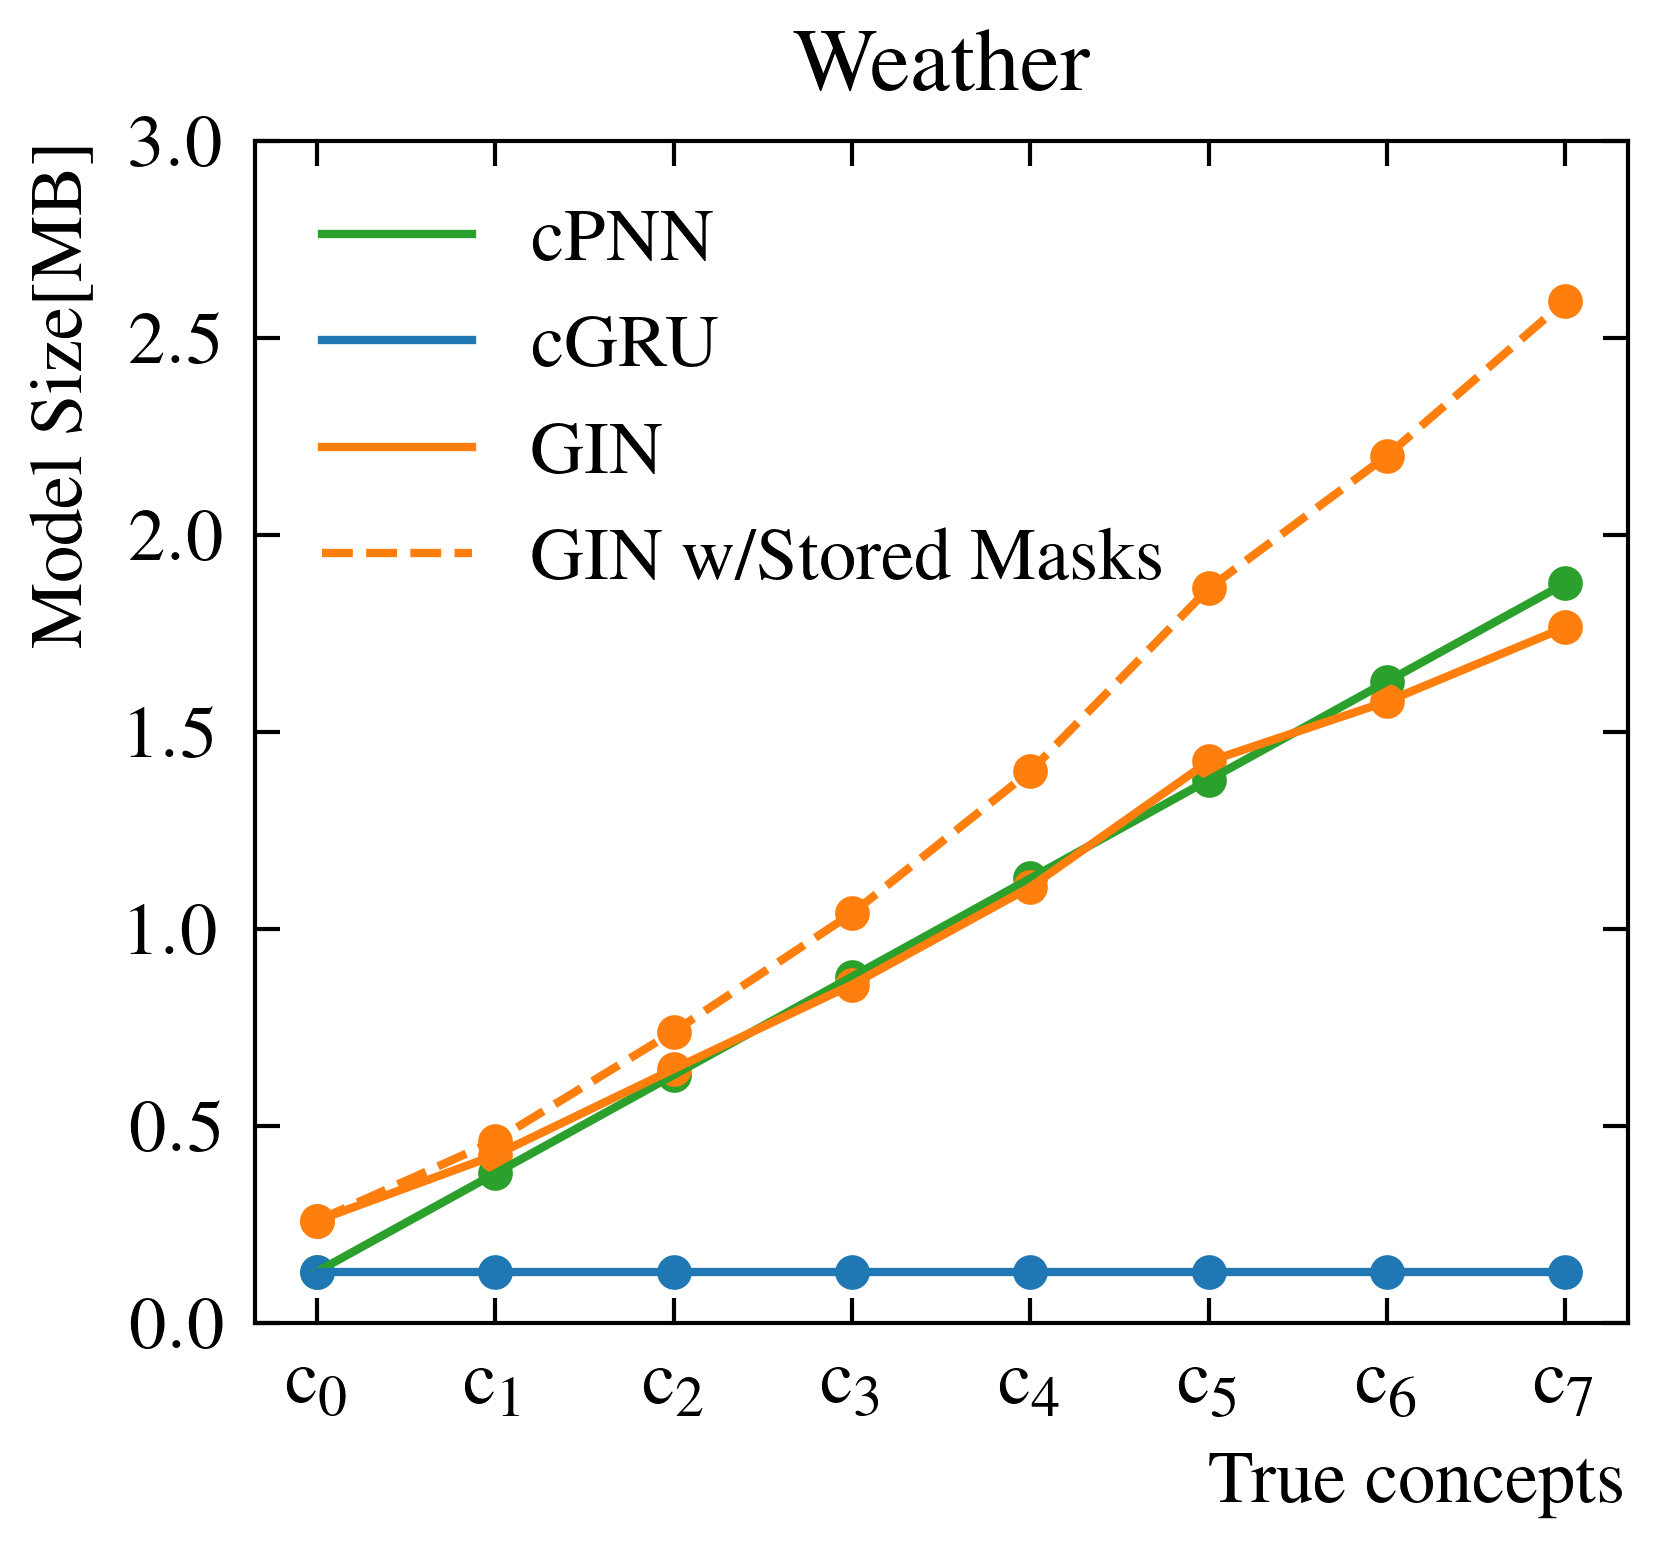

In [26]:
df = pd.DataFrame(avgSizeCL(data_list))
df["concept"] = ["c"+f"$_{{{z}}}$" for z in range(0,8)]

df = df.set_index("concept")
sizeGraph(df)